# Telecom Churn Exploratory Data Analysis

## Goals

- Understand the dataset structure, feature types, and overall data quality.
- Examine missing values, duplicates, and basic data integrity issues.
- Analyze the distribution of the target variable (churn) to understand class balance.
- Explore customer demographics, service usage patterns, and telecom partner distribution.
- Identify relationships between features and churn through visualizations and statistical summaries.
- Detect trends across regions, usage behavior, and customer characteristics.
- Generate insights that will guide the preprocessing and feature engineering stage.

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sns.set_style("whitegrid")

import warnings
warnings.filterwarnings("ignore")


In [48]:
df=pd.read_csv("../../data/raw/telecom_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [50]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce") #errors="coerce":handle dirty data(non-numeric values) by converting them to NaN
df["SeniorCitizen"] = df["SeniorCitizen"].astype(str)

df[["TotalCharges", "SeniorCitizen"]].dtypes

TotalCharges     float64
SeniorCitizen        str
dtype: object

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   str    
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [52]:
print("\nMissing values per column:\n\n", df.isnull().sum())


Missing values per column:

 customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [53]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


In [54]:
for col in df.columns:
    
    unique_vals = df[col].dropna().unique()
    n_unique = df[col].nunique()
    
    # if too many values, print count only
    if n_unique > 20:
        print(f"- {col} → {n_unique} unique values")
    else:
        print(f"- {col} → {list(unique_vals)}")

- customerID → 7043 unique values
- gender → ['Female', 'Male']
- SeniorCitizen → ['0', '1']
- Partner → ['Yes', 'No']
- Dependents → ['No', 'Yes']
- tenure → 73 unique values
- PhoneService → ['No', 'Yes']
- MultipleLines → ['No phone service', 'No', 'Yes']
- InternetService → ['DSL', 'Fiber optic', 'No']
- OnlineSecurity → ['No', 'Yes', 'No internet service']
- OnlineBackup → ['Yes', 'No', 'No internet service']
- DeviceProtection → ['No', 'Yes', 'No internet service']
- TechSupport → ['No', 'Yes', 'No internet service']
- StreamingTV → ['No', 'Yes', 'No internet service']
- StreamingMovies → ['No', 'Yes', 'No internet service']
- Contract → ['Month-to-month', 'One year', 'Two year']
- PaperlessBilling → ['Yes', 'No']
- PaymentMethod → ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']
- MonthlyCharges → 1585 unique values
- TotalCharges → 6530 unique values
- Churn → ['No', 'Yes']


**Unique values per column:**

* **customerID** → 7043 unique values
* **gender** → `['Female', 'Male']`
* **SeniorCitizen** → `[0, 1]` (2 unique values)
* **Partner** → `['Yes', 'No']`
* **Dependents** → `['Yes', 'No']`
* **tenure** → 73 unique values
* **PhoneService** → `['Yes', 'No']`
* **MultipleLines** → `['No', 'Yes', 'No phone service']`
* **InternetService** → `['DSL', 'Fiber optic', 'No']`
* **OnlineSecurity** → `['Yes', 'No', 'No internet service']`
* **OnlineBackup** → `['Yes', 'No', 'No internet service']`
* **DeviceProtection** → `['Yes', 'No', 'No internet service']`
* **TechSupport** → `['Yes', 'No', 'No internet service']`
* **StreamingTV** → `['Yes', 'No', 'No internet service']`
* **StreamingMovies** → `['Yes', 'No', 'No internet service']`
* **Contract** → `['Month-to-month', 'One year', 'Two year']`
* **PaperlessBilling** → `['Yes', 'No']`
* **PaymentMethod** →
  `['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']`
* **MonthlyCharges** → 1585 unique values
* **TotalCharges** → many numeric values (stored as strings)
* **Churn** → `['Yes', 'No']`



# Categorical Columns

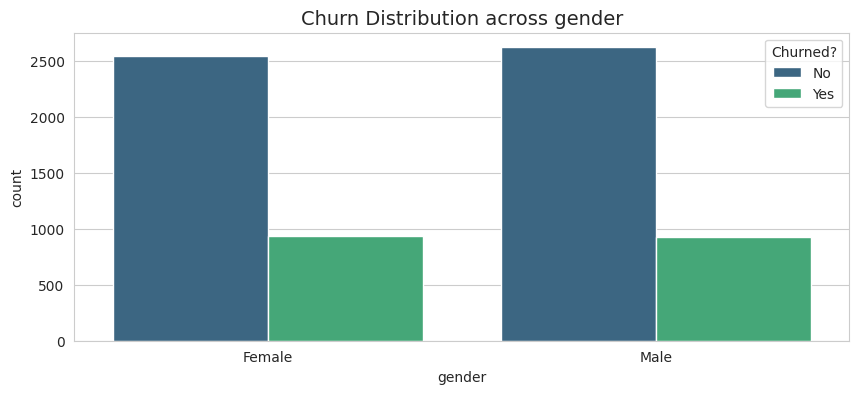

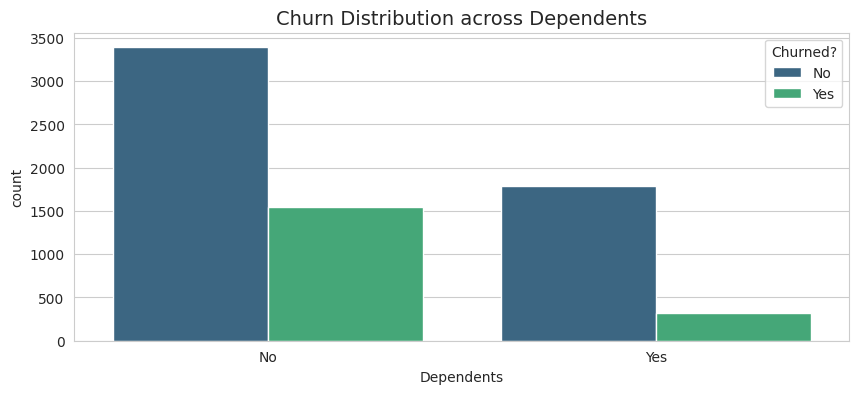

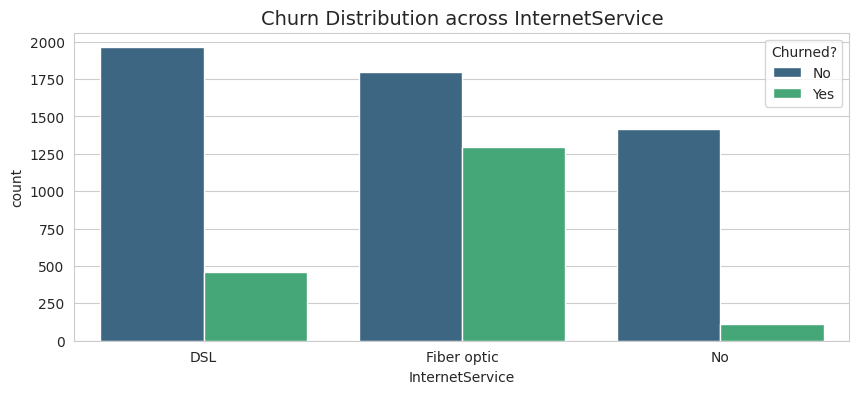

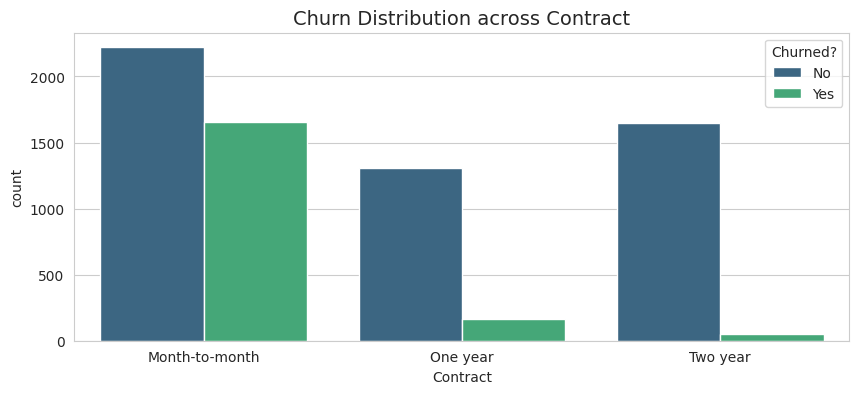

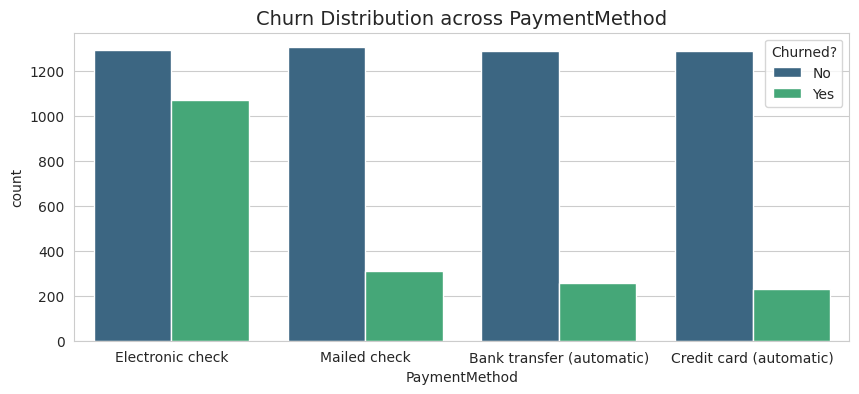

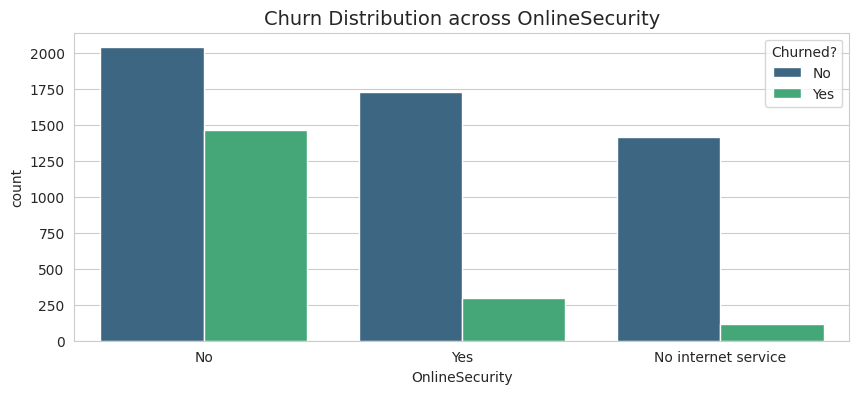

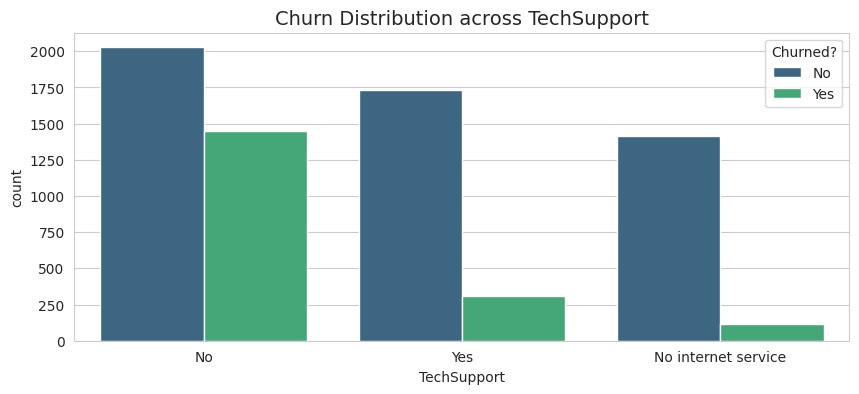

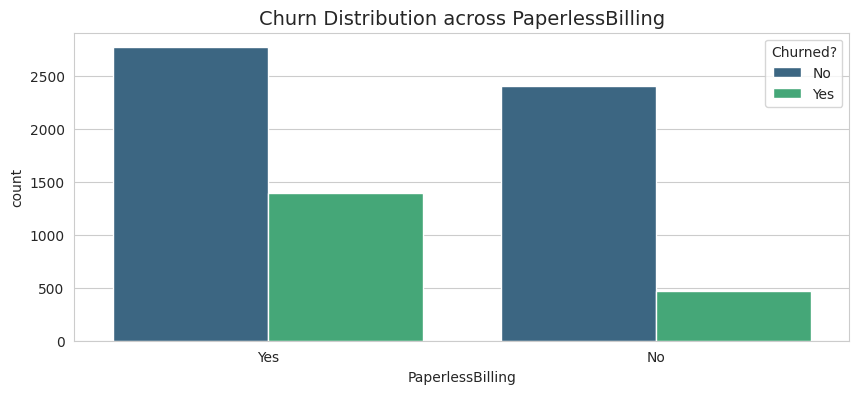

In [55]:
cat_cols = ['gender','Dependents','InternetService','Contract','PaymentMethod',"OnlineSecurity","TechSupport","PaperlessBilling"]

for col in cat_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(x=col, hue="Churn", data=df, palette="viridis")
    plt.title(f"Churn Distribution across {col}", fontsize=14)
    plt.legend(title='Churned?', loc='upper right')
    plt.show()

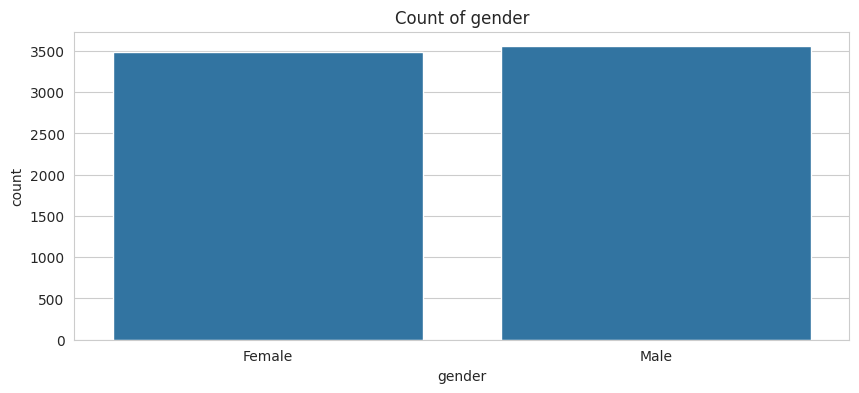

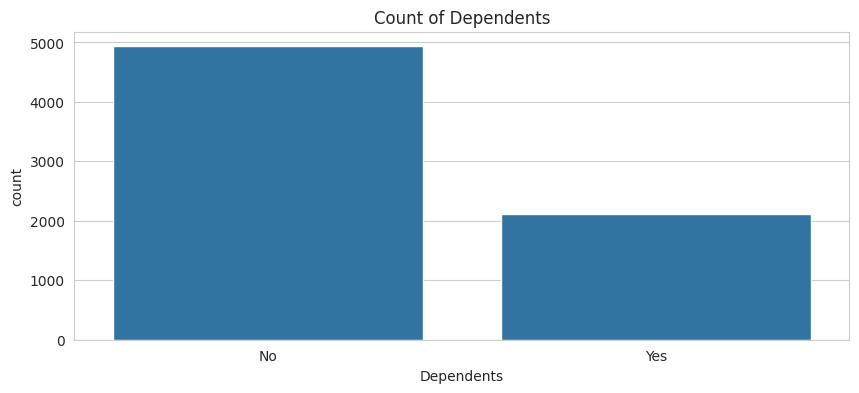

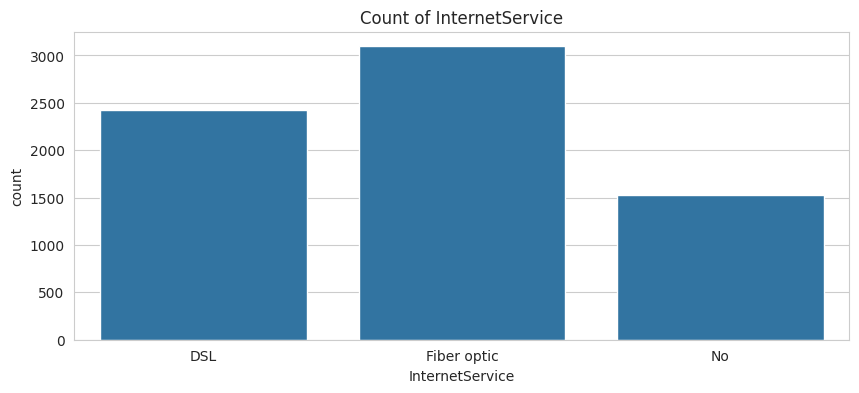

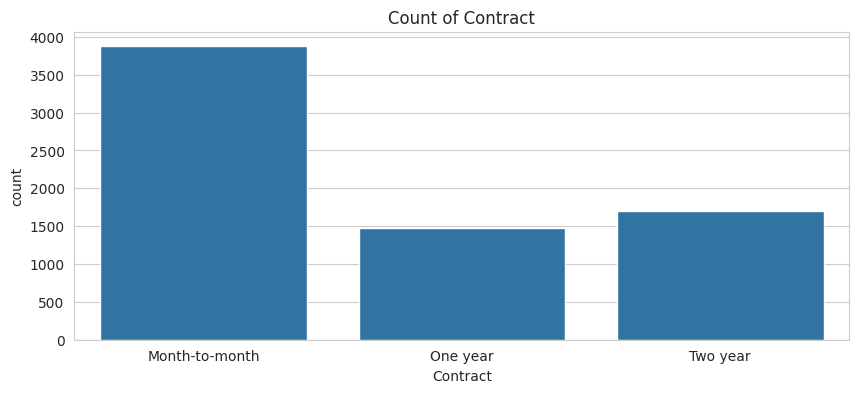

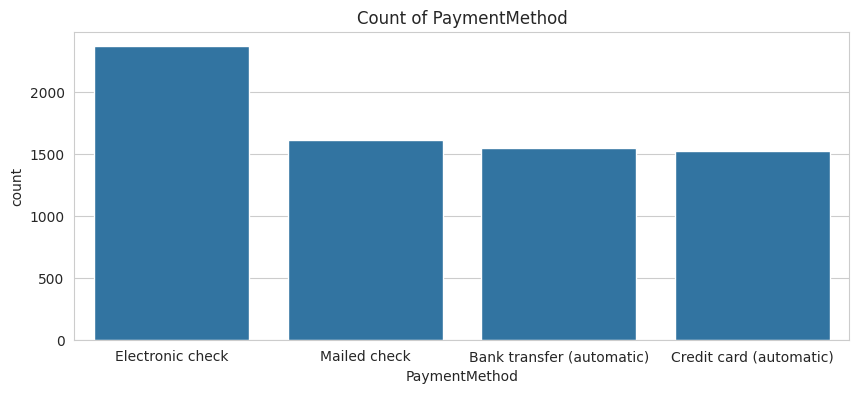

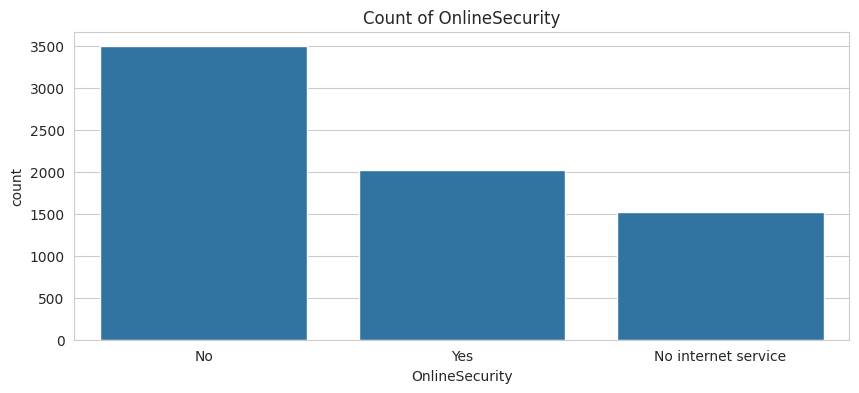

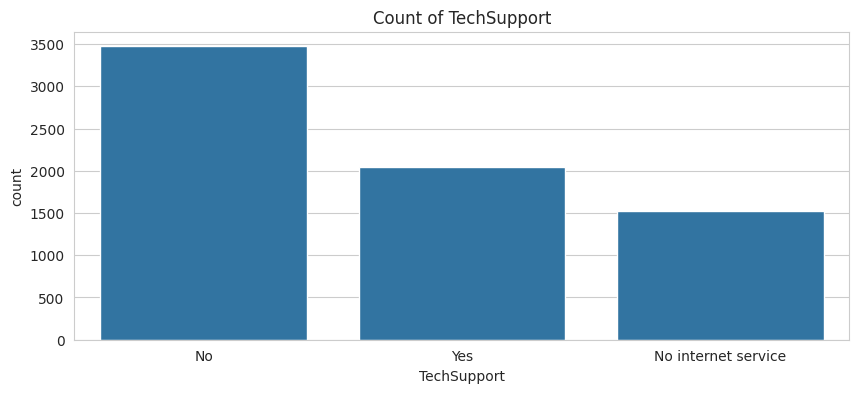

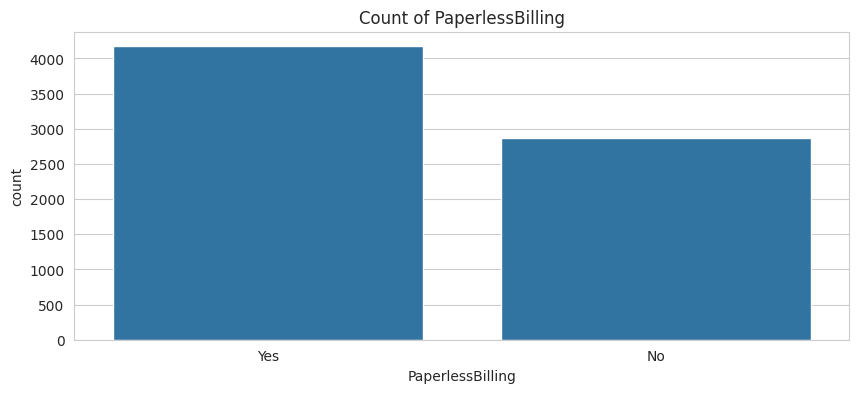

In [56]:
cat_cols = ['gender','Dependents','InternetService','Contract','PaymentMethod',"OnlineSecurity","TechSupport","PaperlessBilling"]


for col in cat_cols:
    plt.figure(figsize=(10,4))
    sns.countplot(x=col, data=df)
    plt.title(f"Count of {col}")
    # plt.xticks(rotation=45)
    plt.show()

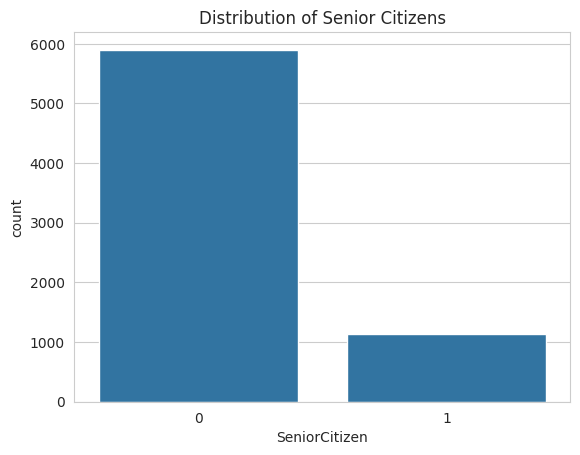

In [57]:
sns.countplot(x="SeniorCitizen", data=df)
plt.title("Distribution of Senior Citizens")
plt.show()

# Numerical Columns  

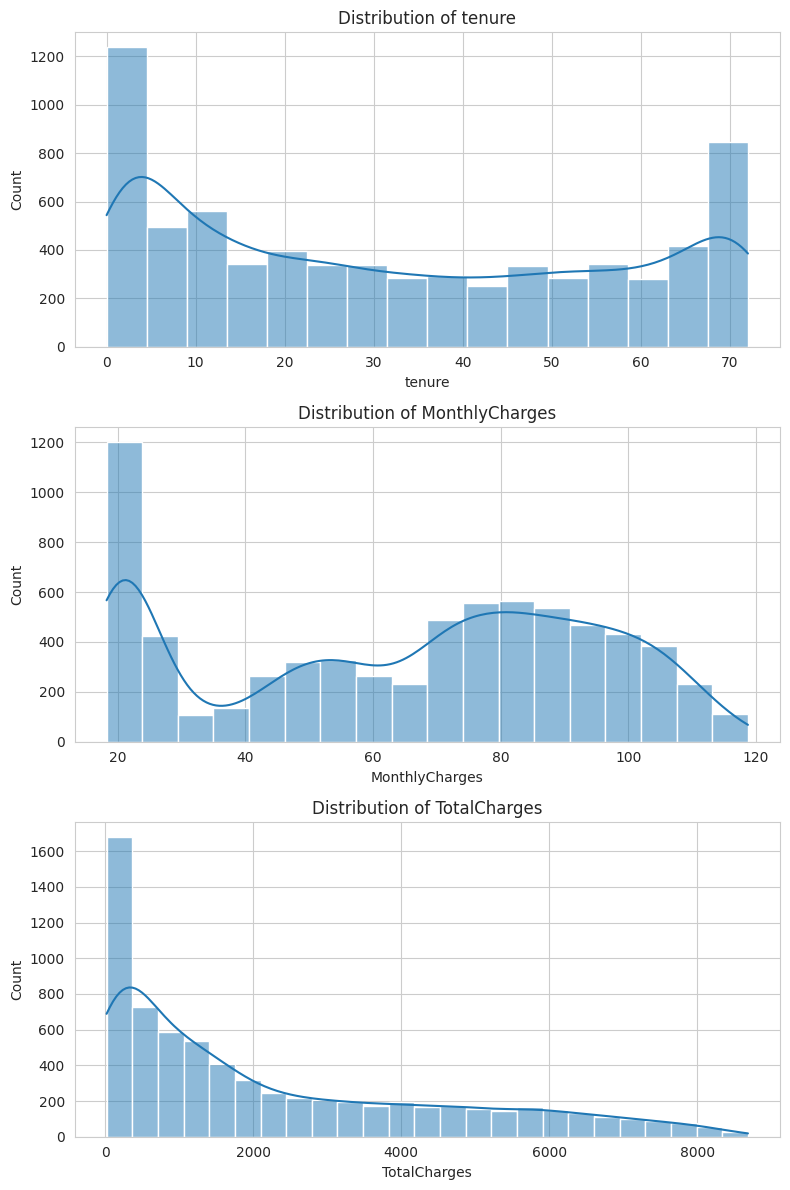

In [58]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(8, 4 * len(numeric_cols)))
if len(numeric_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()

- The Insight: This tells you the company has a lot of "newbies" (high churn risk) and a lot of "loyalists" (long-term veterans). There are actually fewer people in the middle (2–4 years).
- The Insight: Your revenue isn't evenly spread; you have two distinct customer personas: the budget-conscious and the power-users.
- The Insight: This is a natural result of the Tenure graph. Since many customers have only been with the company for a few months, they haven't had time to accumulate high total charges. Only the "loyalists" reach that $6,000–$8,000 range.

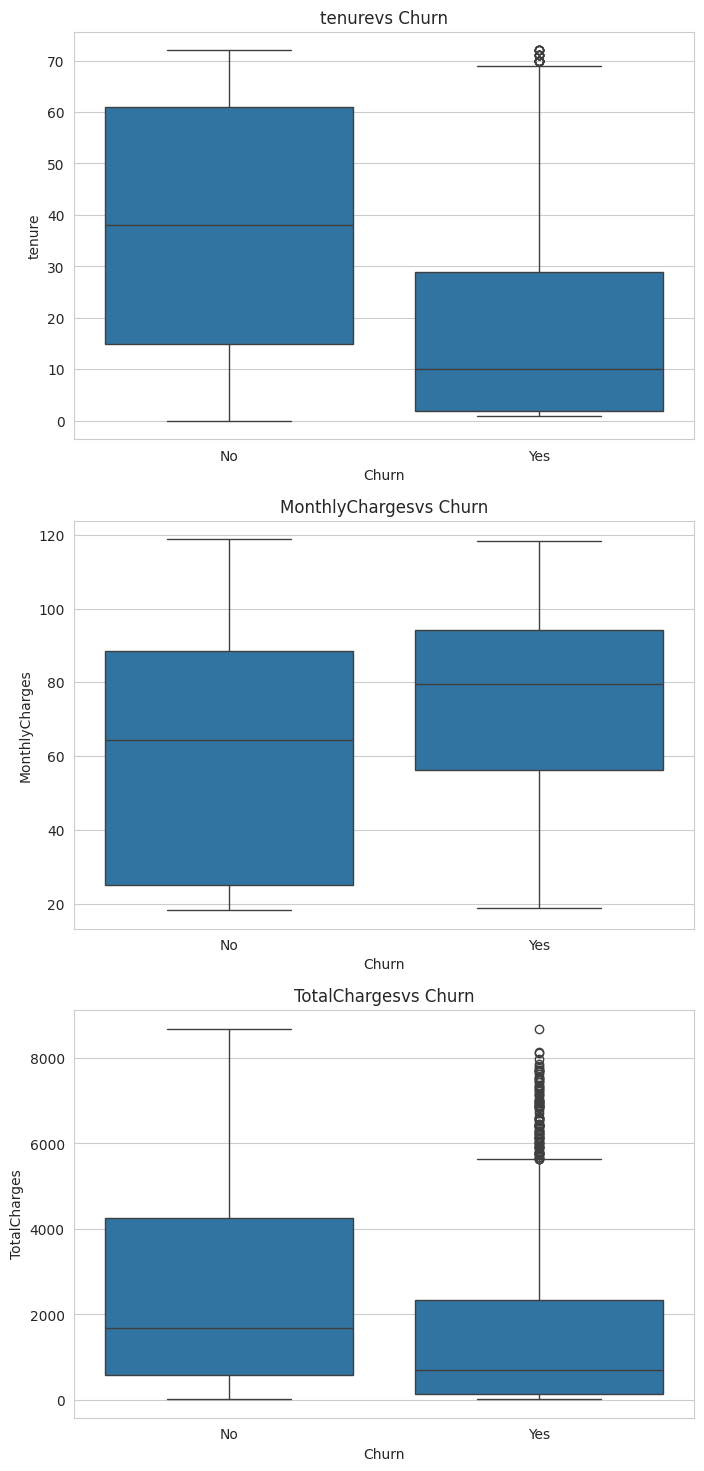

In [59]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(8, 6* len(numeric_cols)))
if len(numeric_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, numeric_cols):
    # sns.histplot(data=df, x=col, kde=True, ax=ax)
    sns.boxplot( data=df,x="Churn", y=col, ax=ax)
    ax.set_title(f"{col}vs Churn")




# Churn  

In [60]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

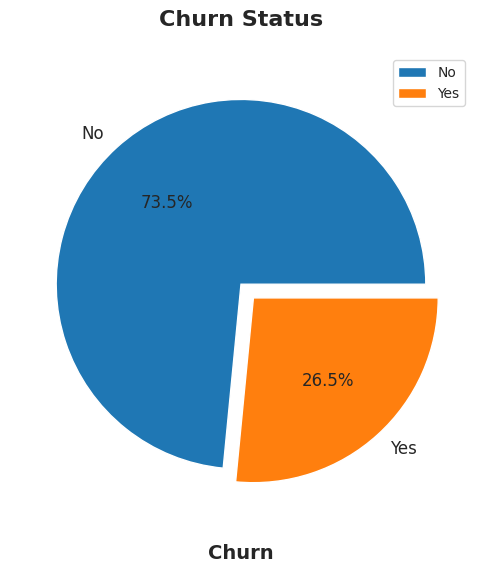

In [61]:
plt.figure(figsize = (20, 6))

counts = df["Churn"].value_counts()
explode = (0, 0.1)

counts.plot(kind = 'pie', fontsize = 12, explode = explode, autopct = '%.1f%%')
plt.title('Churn Status', weight = "bold", fontsize = 16, pad = 20)
plt.xlabel('Churn', weight = "bold", fontsize = 14, labelpad = 20)

plt.legend(labels =counts.index, loc = "best")
plt.show()

In [62]:
df.drop(columns=["customerID"], inplace=True)

# convert Yes/No columns
yes_no_cols = [
    "Partner","Dependents","PhoneService","PaperlessBilling",
    "Churn","OnlineSecurity","OnlineBackup","DeviceProtection",
    "TechSupport","StreamingTV","StreamingMovies"
]

for col in yes_no_cols:
    df[col] = df[col].replace({"Yes":1, "No":0, "No internet service":0, "No phone service":0})

In [63]:
df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,No phone service,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,No,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,Male,0,0,0,2,1,No,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,0,No phone service,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,1,No,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [64]:
features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "OnlineSecurity",
    "TechSupport",
    "PaperlessBilling",
    "Churn"
]

corr = df[features].corr()

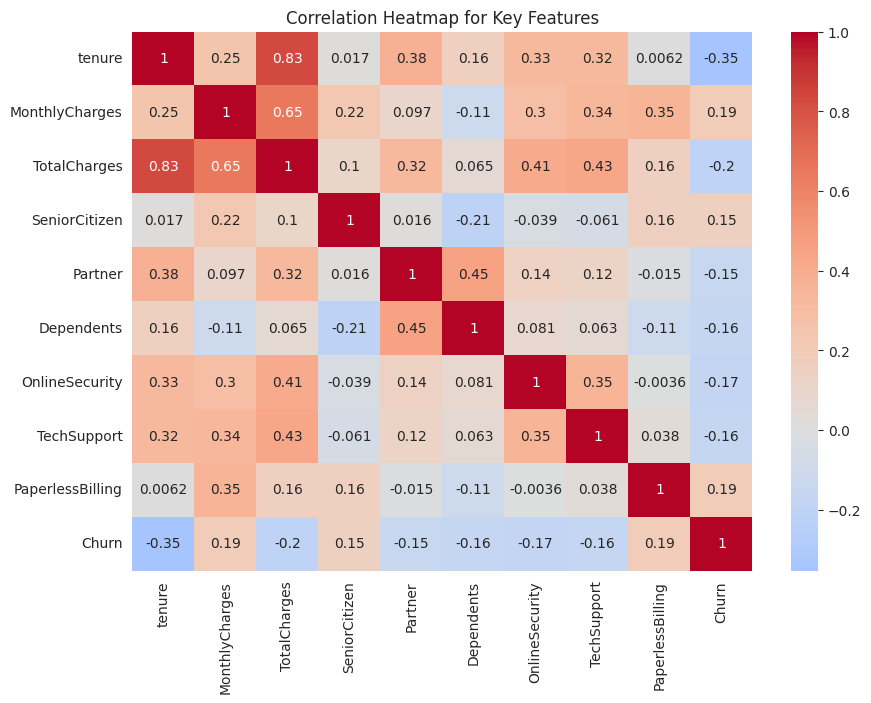

In [66]:
plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)

plt.title("Correlation Heatmap for Key Features")
plt.show()